In [1]:
from pathlib import Path
#import numpy as np
import matplotlib.pyplot as plt
#import matplotlib.gridspec as gridspec
import pandas as pd
import openpyxl


In [2]:
# Dictionary met kleuren en markers
player_styles = {
    "Max": {'color': '#FF6B6B', 'marker': 'o'},
    "Enzo": {'color': '#4ECDC4', 'marker': 's'},
    "Antoine": {'color': "#0E4552", 'marker': '^'},
    "Ma": {'color': '#FFA07A', 'marker': 'd'},
    "Pa": {'color': "#98D8AD", 'marker': 'v'}
}

In [3]:
#spelers
players = ["Max", "Enzo", "Antoine", "Ma", "Pa"]

# Definieer vaste kleuren per speler
player_colors = {
    "Max": "#14581699",
    "Enzo": "#DDBF3BA4",
    "Antoine": "#0A53C2",
    "Ma": '#FFA07A',
    "Pa": "#72F79E"
}

#symbool
player_symbol = {
    "Max": "o",
    "Enzo": 'h',
    "Antoine": "v",
    "Ma": 's',
    "Pa": "d"
}


In [4]:
name_excelfile = "Catan_RawData_Copy.xlsx"
#open path to the excel file
path_to_folder = "/home/antoine-zijlstra/Coderen/WebsiteCatan/"
excel_path = Path(f"{path_to_folder}Data/Excel/Catan_RawData_Copy.xlsx")
##__file__ bestaat niet in jupyternotebook; alleen in python
print(f"excel_path:{excel_path}")


excel_path:/home/antoine-zijlstra/Coderen/WebsiteCatan/Data/Excel/Catan_RawData_Copy.xlsx


In [5]:
#Getting sheet names
wb = openpyxl.load_workbook(excel_path)
sheet_names = wb.sheetnames
print(f"sheet_names:{sheet_names}")

sheet_names:['Blad1']


In [6]:
#leest de hele file
file_original = pd.read_excel(excel_path, sheet_name="Blad1", engine="openpyxl")
#Create a copy of the original file
file = file_original.copy() 
print(f"file:\n{file}")

file:
        Datum Max Enzo Antoine  Ma  Pa    Begon     Bank    Comment  \
0  2022-08-09  11    9       7   5  10      NaN      NaN        NaN   
1  2022-08-13   4    9      11   9   9      NaN      NaN        NaN   
2  2022-08-16   8    8       7   6  11      NaN      NaN        NaN   
3  2022-08-19   6    7       9   8  11      NaN      NaN        NaN   
4  2022-08-20   8   11       8   7   5      NaN      NaN        NaN   
..        ...  ..  ...     ...  ..  ..      ...      ...        ...   
70 2026-05-10  11    6      10  10   7     Enzo       Ma  Moederdag   
71 2026-06-07   9   11       9  10   x  Antoine  Antoine        NaN   
72 2026-07-16  11    7       9   6   7       Ma       Ma     Ostuni   
73 2026-07-20   7    8       7  11   4     Enzo       Ma     Ostuni   
74 2026-07-21  11    6       9   8   7     Enzo      Max     Ostuni   

    Potjes(#)  Potjes in een jaar(#)  
0           1                      1  
1           2                      2  
2           3           

In [7]:
# Get all columns (except index/names)
data = file[["Datum", "Max", "Enzo", "Antoine", "Ma", "Pa", "Begon", "Bank", "Potjes(#)", "Potjes in een jaar(#)"]]
data["Datum"] = pd.to_datetime(data["Datum"], format="%d-%m-%Y") #The right format for the date
print(f"Datums:\n{data["Datum"][0]}")
print(data.dtypes)

Datums:
2022-08-09 00:00:00
Datum                    datetime64[us]
Max                              object
Enzo                             object
Antoine                          object
Ma                               object
Pa                               object
Begon                               str
Bank                                str
Potjes(#)                         int64
Potjes in een jaar(#)             int64
dtype: object


In [8]:
#Reverse the order of the data to have the oldest first
d1 = data["Datum"][0]
d2 = data["Datum"][1]
if d1 < d2:
   print("De oudste datum staat eerst")
   print(f"{data[["Datum", "Max"]]}")
else:
   data = file.iloc[::-1].reset_index(drop=True)
   print(f"De nieuwste datum stond eerst:\n{data[["Datum", "Max"]]}")

De oudste datum staat eerst
        Datum Max
0  2022-08-09  11
1  2022-08-13   4
2  2022-08-16   8
3  2022-08-19   6
4  2022-08-20   8
..        ...  ..
70 2026-05-10  11
71 2026-06-07   9
72 2026-07-16  11
73 2026-07-20   7
74 2026-07-21  11

[75 rows x 2 columns]


In [9]:
#x vervangen door 0
print(f"oude data types:\n{data[["Max", "Enzo", "Antoine", "Ma", "Pa"]].dtypes}")
data_x0 = data[["Max", "Enzo", "Antoine", "Ma", "Pa"]].replace("x", 0, inplace=False)#nummer nodig om er een int64 te maken
data_x0 = data_x0.apply(pd.to_numeric, errors="coerce")
print(data_x0)
print(f"Nieuwe data types:\n{data_x0.dtypes}")

oude data types:
Max        object
Enzo       object
Antoine    object
Ma         object
Pa         object
dtype: object
    Max  Enzo  Antoine  Ma  Pa
0    11     9        7   5  10
1     4     9       11   9   9
2     8     8        7   6  11
3     6     7        9   8  11
4     8    11        8   7   5
..  ...   ...      ...  ..  ..
70   11     6       10  10   7
71    9    11        9  10   0
72   11     7        9   6   7
73    7     8        7  11   4
74   11     6        9   8   7

[75 rows x 5 columns]
Nieuwe data types:
Max        int64
Enzo       int64
Antoine    int64
Ma         int64
Pa         int64
dtype: object


save_path: /home/antoine-zijlstra/Coderen/WebsiteCatan/Data/Graphs/Catan_TotaleScores_Alles.png
Plot saved as Catan_TotaleScores_Alles.png in path: /home/antoine-zijlstra/Coderen/WebsiteCatan/Data/Graphs/Catan_TotaleScores_Alles.png


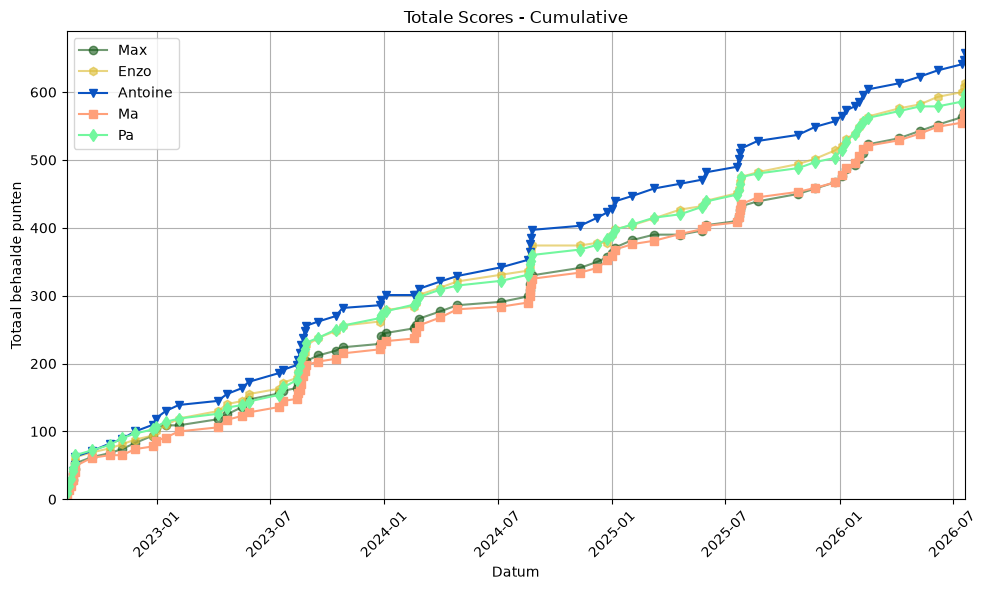

In [10]:
#Plot all cumulative scores
plt.figure (figsize=(10, 6))
for column in data_x0[["Max", "Enzo", "Antoine", "Ma", "Pa"]]:
   plt.plot(data["Datum"],
            data_x0[column].cumsum(),
            label=column,
            color=player_colors[column],
            marker=player_symbol[column])
   

plt.xlim(data["Datum"].min(), data["Datum"].max())
plt.ylim(ymin=0)
plt.xlabel("Datum")#De dagen waarop niet gespeeld weghalen.
plt.ylabel("Totaal behaalde punten")
plt.title("Totale Scores - Cumulative")#Andere titel

plt.legend()
plt.grid(True)
plt.xticks(rotation=45)#draait de x-as
plt.tight_layout()

#Save part
name_graphfile = "Catan_TotaleScores_Alles.png" #aanpassen voor elke grafiek; Gelijk zetten aan de titel van de grafiek
save_path = Path(f"{path_to_folder}/Data/Graphs")
#save_path.mkdir(exist_ok=True) # To remove the error codes; it makes the map

save_path = save_path / name_graphfile # for checking the path
print(f"save_path: {save_path}")

plt.savefig(save_path, dpi=300, bbox_inches="tight")
print(f"Plot saved as {name_graphfile} in path: {save_path}")

plt.show() #FigureCanvassAgg is non-interactive dus word niet getoond.

save_path: /home/antoine-zijlstra/Coderen/WebsiteCatan/Data/Graphs/Catan_TotaleScores_Alles_ZonderDatum.png
Plot saved as Catan_TotaleScores_Alles_ZonderDatum.png in path: /home/antoine-zijlstra/Coderen/WebsiteCatan/Data/Graphs/Catan_TotaleScores_Alles_ZonderDatum.png


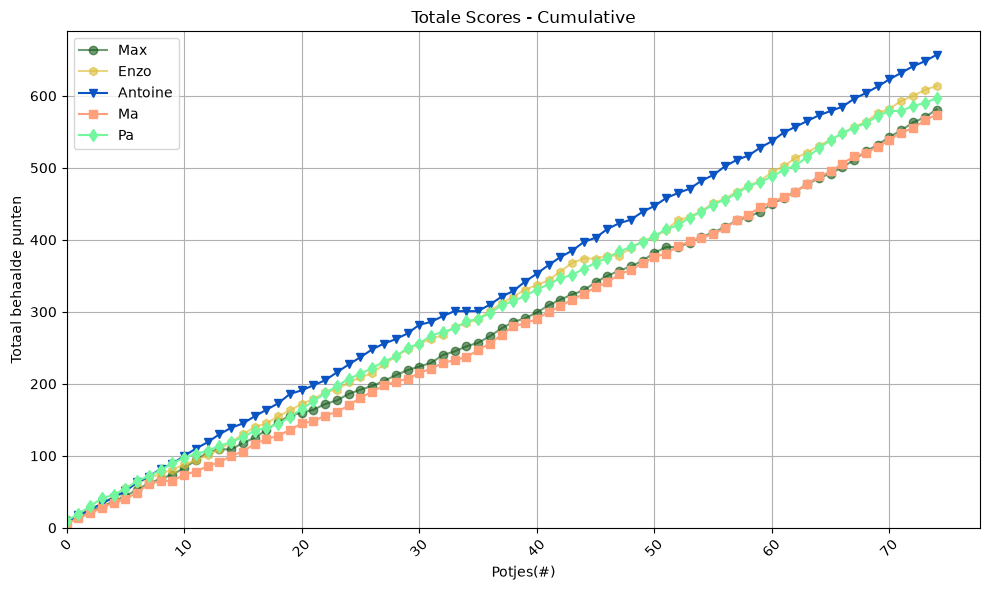

In [11]:
#Plot all cumulative scores
plt.figure (figsize=(10, 6))
for column in data_x0[["Max", "Enzo", "Antoine", "Ma", "Pa"]]:
   plt.plot(data_x0[column].cumsum(),
            label=column,
            color=player_colors[column],
            marker=player_symbol[column])
   

plt.xlim(xmin=0)
plt.ylim(ymin=0)
plt.xlabel("Potjes(#)")#De dagen waarop niet gespeeld weghalen.
plt.ylabel("Totaal behaalde punten")
plt.title("Totale Scores - Cumulative")#Andere titel

plt.legend()
plt.grid(True)
plt.xticks(rotation=45)#draait de x-as
plt.tight_layout()

#Save part
name_graphfile = "Catan_TotaleScores_Alles_ZonderDatum.png" #aanpassen voor elke grafiek; Gelijk zetten aan de titel van de grafiek
save_path = Path(f"{path_to_folder}/Data/Graphs")
#save_path.mkdir(exist_ok=True) # To remove the error codes; it makes the map

save_path = save_path / name_graphfile # for checking the path
print(f"save_path: {save_path}")

plt.savefig(save_path, dpi=300, bbox_inches="tight")
print(f"Plot saved as {name_graphfile} in path: {save_path}")

plt.show() #FigureCanvassAgg is non-interactive dus word niet getoond.

In [ ]:
players = ["Max", "Enzo", "Antoine", "Ma", "Pa"]

# Maak DataFrame met alleen scores
scores = data_x0[players].copy()
print(f"scores:{scores}\n{scores.dtypes}")

# Vervang 0 met NaN (zodat die niet meegenomen worden in ranking)
scores = scores.replace(0, float('nan'))

# Rank elke rij (1 = laagste, 5 = hoogste)
ranks = scores.rank(axis=1, method='min', ascending=False)
#print(f"ranks:\n{ranks}")


# Zet ranks om naar punten (1e = 5pt, 2e = 4pt, etc.)
points = 6 - ranks
#print(f"punten:{points}\n{points.dtypes}")
---------------------------------------------
# Voeg toe aan data_x0
#for player in players:
#    data_x0[f"{player}_Points"] = points[player].astype(int)

#print(data_x0[["Max", "Enzo", "Antoine", "Ma", "Pa",
#            "Max_Points", "Enzo_Points", "Antoine_Points", "Ma_Points", "Pa_Points"]])

#ranks = ranks.apply(pd.to_numeric, errors="coerce")
#Doet nog niks
point_columns = [f"{player}_Points" for player in players]
data_x0[point_columns] = data_x0[point_columns].fillna(0).astype('int64')
print(f"help \n{ranks.dtypes}")
print(data_x0.dtypes)

# Bereken totale punten per speler
point_columns = [f"{player}_Points" for player in players]
totals = data_x0[point_columns].sum()

# Bereken totale punten per speler
print("\nTotale Punten:")
for player in players:
    total = data_x0[f"{player}_Points"].sum()
    print(f"{player}: {total} punten")

# Ranking
total_points = {}
for player in players:
    total_points[player] = data_x0[f"{player}_Points"].sum()

ranking = sorted(total_points.items(), key=lambda x: x[1], reverse=True)
print("\nRanking:")
for rank, (player, points) in enumerate(ranking, 1):
    print(f"{rank}. {player}: {points} punten")

scores:    Max  Enzo  Antoine  Ma  Pa
0    11     9        7   5  10
1     4     9       11   9   9
2     8     8        7   6  11
3     6     7        9   8  11
4     8    11        8   7   5
..  ...   ...      ...  ..  ..
70   11     6       10  10   7
71    9    11        9  10   0
72   11     7        9   6   7
73    7     8        7  11   4
74   11     6        9   8   7

[75 rows x 5 columns]
Max        int64
Enzo       int64
Antoine    int64
Ma         int64
Pa         int64
dtype: object


KeyError: "None of [Index(['Max_Points', 'Enzo_Points', 'Antoine_Points', 'Ma_Points',\n       'Pa_Points'],\n      dtype='str')] are in the [columns]"

In [ ]:
#kampioenspunten
data_x0

#Plot all cumulative scores
plt.figure (figsize=(10, 6))
for column in data_x0[["Max", "Enzo", "Antoine", "Ma", "Pa"]]:
   plt.plot(data_x0[column].cumsum(),
            label=column,
            color=player_colors[column],
            marker=player_symbol[column])
   

plt.xlim(xmin=0)
plt.ylim(ymin=0)
plt.xlabel("Potjes(#)")#De dagen waarop niet gespeeld weghalen.
plt.ylabel("Kampioenspunten")
plt.title("Kampioenspunten - Alltime")#Andere titel

plt.legend()
plt.grid(True)
plt.xticks(rotation=45)#draait de x-as
plt.tight_layout()

#Save part
name_graphfile = "Catan_Kampioenspunten.png" #aanpassen voor elke grafiek; Gelijk zetten aan de titel van de grafiek
save_path = Path(f"{path_to_folder}/Data/Graphs")
#save_path.mkdir(exist_ok=True) # To remove the error codes; it makes the map

save_path = save_path / name_graphfile # for checking the path
print(f"save_path: {save_path}")

plt.savefig(save_path, dpi=300, bbox_inches="tight")
print(f"Plot saved as {name_graphfile} in path: {save_path}")

plt.show() #FigureCanvassAgg is non-interactive dus word niet getoond.

,Max,Enzo,Antoine,Ma,Pa
0,11,9,7,5,10
1,4,9,11,9,9
2,8,8,7,6,11
3,6,7,9,8,11
4,8,11,8,7,5
...,...,...,...,...,...
70,11,6,10,10,7
71,9,11,9,10,0
72,11,7,9,6,7
73,7,8,7,11,4


save_path: /home/antoine-zijlstra/Coderen/WebsiteCatan/Data/Graphs/Catan_Histogram_Iedereenlos.png
Plot saved as Catan_Histogram_Iedereenlos.png in path: /home/antoine-zijlstra/Coderen/WebsiteCatan/Data/Graphs/Catan_Histogram_Iedereenlos.png


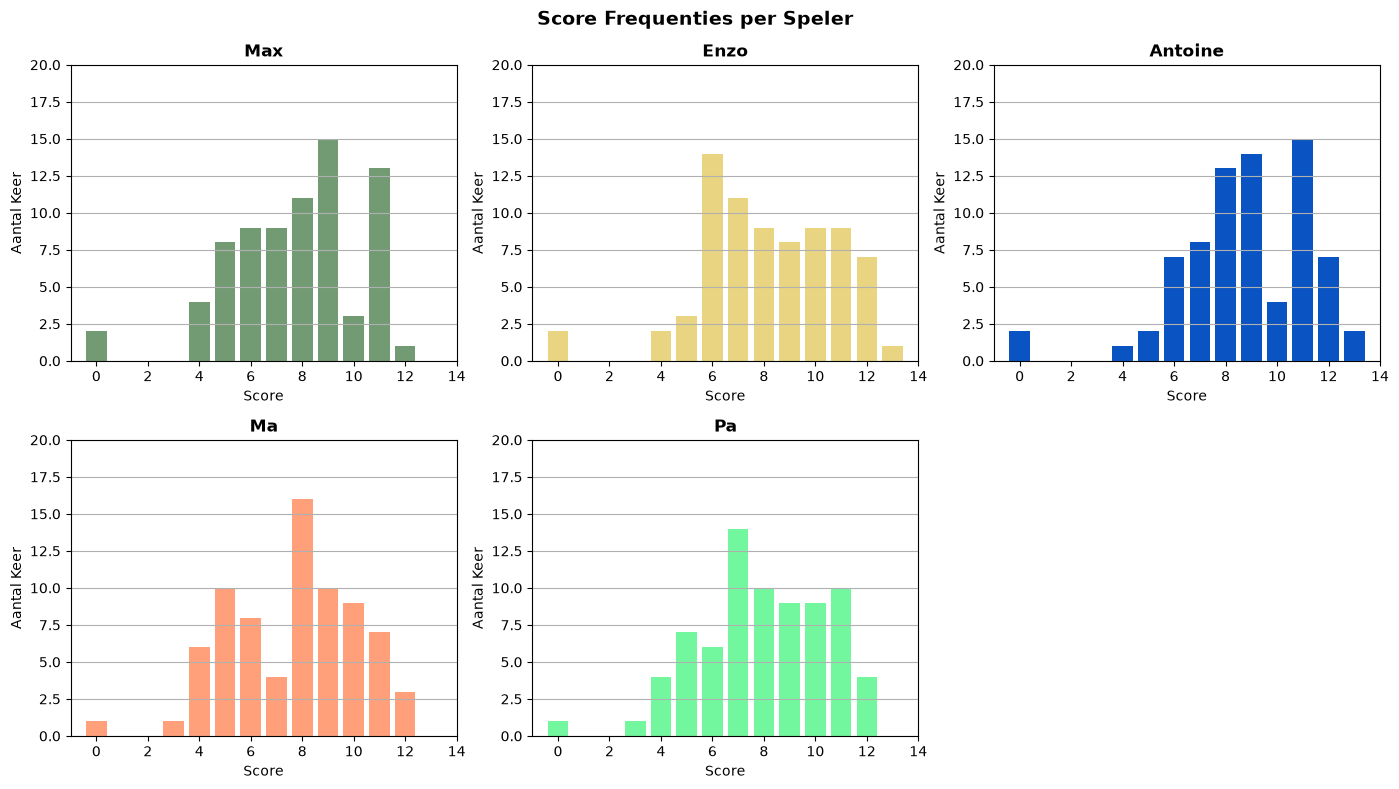

In [ ]:
#Histogrammen maken iedereen los
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, player in enumerate(players):
    score_freq = data_x0[player].value_counts().sort_index()
    
    axes[i].bar(score_freq.index, score_freq.values, color=player_colors[player],)
    axes[i].set_title(f"{player}", fontsize=12, fontweight="bold")
    axes[i].set_xlabel("Score")
    axes[i].set_ylabel("Aantal Keer")
    axes[i].grid(axis='y')
    axes[i].set_xlim(-1, 14)
    axes[i].set_ylim(0, 20)

axes[5].set_visible(False)

plt.suptitle("Score Frequenties per Speler", fontsize=14, fontweight='bold')
plt.tight_layout()

#save naar de Graphs map in de Data map
name_graphfile = "Catan_Histogram_Iedereenlos.png" #aanpassen voor elke grafiek; Gelijk zetten aan de titel van de grafiek
save_path = Path(f"{path_to_folder}/Data/Graphs")
#save_path.mkdir(exist_ok=True) # To remove the error codes; it makes the map

save_path = save_path / name_graphfile # for checking the path
print(f"save_path: {save_path}")

plt.savefig(save_path, dpi=300, bbox_inches="tight")
print(f"Plot saved as {name_graphfile} in path: {save_path}")

plt.show() #FigureCanvassAgg is non-interactive dus word niet getoond.

save_path: /home/antoine-zijlstra/Coderen/WebsiteCatan/Data/Graphs/Piechart_Begon_Bank.png
Plot saved as Piechart_Begon_Bank.png in path: /home/antoine-zijlstra/Coderen/WebsiteCatan/Data/Graphs/Piechart_Begon_Bank.png


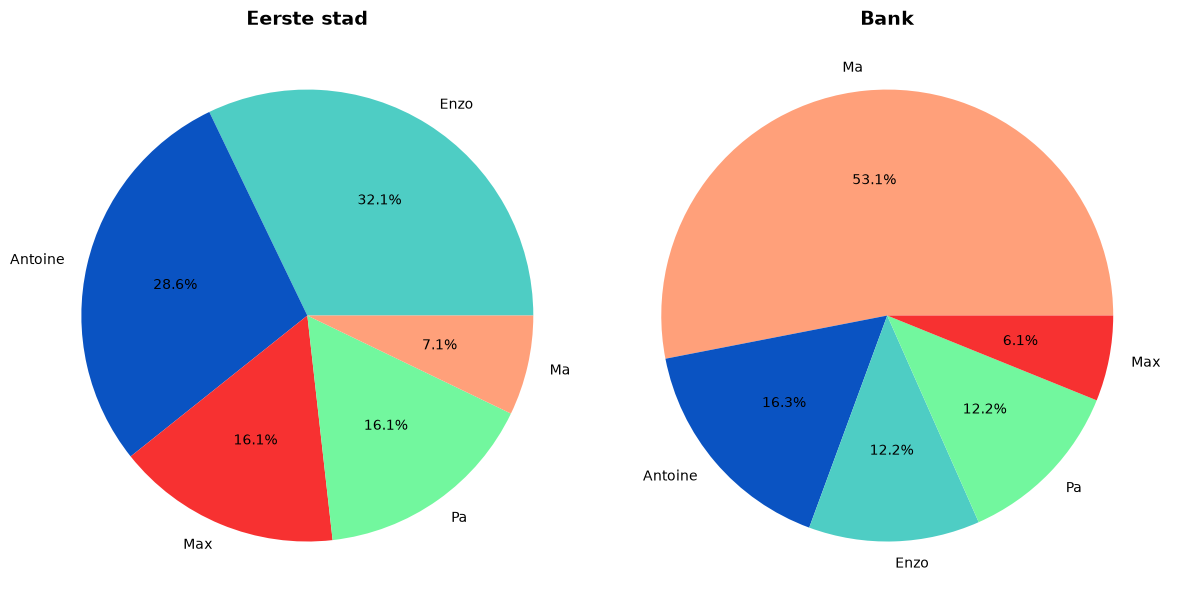

In [ ]:
data[["Begon", "Bank"]]
begon_counts = data["Begon"].value_counts()
bank_counts = data["Bank"].value_counts()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,6))

# Zet kleuren in juiste volgorde
begon_colors = [player_colors[player] for player in begon_counts.index]
bank_colors = [player_colors[player] for player in bank_counts.index]

#Begon
ax1.pie(begon_counts.values,
       labels=begon_counts.index, 
       colors=begon_colors, 
       autopct='%1.1f%%')
ax1.set_title("Eerste stad", fontsize=14, fontweight="bold")

#Bank
ax2.pie(bank_counts.values, 
       labels=bank_counts.index, 
       colors=bank_colors, 
       autopct='%1.1f%%')
ax2.set_title("Bank", fontsize=14, fontweight="bold")

plt.tight_layout()

#save naar de Graphs map in de Data map
name_graphfile = "Piechart_Begon_Bank.png" #aanpassen voor elke grafiek; Gelijk zetten aan de titel van de grafiek
save_path = Path(f"{path_to_folder}/Data/Graphs")
#save_path.mkdir(exist_ok=True) # To remove the error codes; it makes the map

save_path = save_path / name_graphfile # for checking the path
print(f"save_path: {save_path}")

plt.savefig(save_path, dpi=300, bbox_inches="tight")
print(f"Plot saved as {name_graphfile} in path: {save_path}")

plt.show() #FigureCanvassAgg is non-interactive dus word niet getoond.
